# EDA: Air Quality Prediction

In [8]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
DATA_PATH = Path("../data/AirQualityUCI.csv")

df = pd.read_csv(DATA_PATH, sep=";", decimal=",", na_values=-200)
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16']).dropna(how='all')
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'].str.replace('.', ':'),
    format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time'])


In [3]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


In [10]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")
print(f"Data period: {df['DateTime'].min()} - {df['DateTime'].max()}")

Number of rows: 9,357
Number of columns: 14
Data period: 2004-03-10 18:00:00 - 2005-04-04 14:00:00


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CO(GT)         7674 non-null   float64       
 1   PT08.S1(CO)    8991 non-null   float64       
 2   NMHC(GT)       914 non-null    float64       
 3   C6H6(GT)       8991 non-null   float64       
 4   PT08.S2(NMHC)  8991 non-null   float64       
 5   NOx(GT)        7718 non-null   float64       
 6   PT08.S3(NOx)   8991 non-null   float64       
 7   NO2(GT)        7715 non-null   float64       
 8   PT08.S4(NO2)   8991 non-null   float64       
 9   PT08.S5(O3)    8991 non-null   float64       
 10  T              8991 non-null   float64       
 11  RH             8991 non-null   float64       
 12  AH             8991 non-null   float64       
 13  DateTime       9357 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(13)
memory usage: 1023.6 KB


In [7]:
df.dtypes

CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
DateTime         datetime64[us]
dtype: object

In [12]:
df.sample(5, random_state=42)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
2973,1.3,933.0,NaN,6.4,831.0,105.0,888.0,72.0,1514.0,710.0,26.0,34.9,1.1509,2004-07-12 15:00:00
3396,NaN,894.0,NaN,4.9,761.0,36.0,862.0,48.0,1504.0,768.0,23.0,49.9,1.3849,2004-07-30 06:00:00
4372,2.6,1226.0,NaN,14.6,1138.0,307.0,862.0,146.0,1481.0,1419.0,25.1,32.3,1.0131,2004-09-08 22:00:00
6025,3.1,1101.0,NaN,14.5,1134.0,427.0,683.0,168.0,1283.0,1281.0,13.6,34.0,0.5251,2004-11-16 19:00:00
7960,1.3,966.0,NaN,4.9,760.0,302.0,877.0,200.0,890.0,940.0,7.5,39.2,0.4091,2005-02-05 10:00:00


In [14]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,9357
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530,2004-09-21 16:00:00
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,2004-03-10 18:00:00
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800,2004-06-16 05:00:00
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400,2004-09-21 16:00:00
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700,2004-12-28 03:00:00
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,2005-04-04 14:00:00
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813,NaN


In [ ]:
target = "C6H6(GT)"
sensor_features = [
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)"
]
environment_features = ["T", "RH", "AH"]
other_pollutant_features = [
    "CO(GT)",
    "NOx(GT)",
    "NO2(GT)"
]
feature_columns = sensor_features + environment_features
analysis_columns = (
    sensor_features
    + environment_features
    + other_pollutant_features
    + ["NMHC(GT)", target]
)
print("Target:", target)
print("Key features:", feature_columns)
print("Reference pollutant:", other_pollutant_features)

Target: C6H6(GT)
Key features: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Reference pollutant: ['CO(GT)', 'NOx(GT)', 'NO2(GT)']


In [15]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100)
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
NMHC(GT),8443,90.231912
CO(GT),1683,17.986534
NO2(GT),1642,17.548360
NOx(GT),1639,17.516298
C6H6(GT),366,3.911510
PT08.S1(CO),366,3.911510
PT08.S2(NMHC),366,3.911510
PT08.S3(NOx),366,3.911510
PT08.S4(NO2),366,3.911510
PT08.S5(O3),366,3.911510


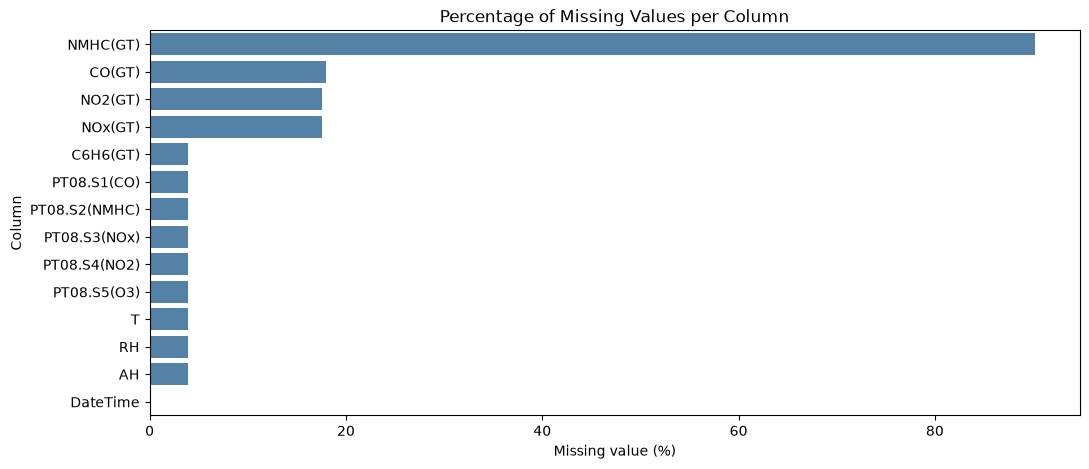

In [16]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=missing_summary.reset_index(),
    x="missing_percent",
    y="index",
    color="steelblue"
)

plt.title("Percentage of Missing Values per Column")
plt.xlabel("Missing value (%)")
plt.ylabel("Column")
plt.show()

In [18]:
print("Number of duplicates:", df.duplicated().sum())
print("Number of empty DateTime:", df["DateTime"].isna().sum())
print("Number of duplicate DateTime:", df["DateTime"].duplicated().sum())
print("Sorted data:", df["DateTime"].is_monotonic_increasing)

Number of duplicates: 0
Number of empty DateTime: 0
Number of duplicate DateTime: 0
Sorted data: True


In [19]:
time_gap = df["DateTime"].diff().value_counts().head(10)
time_gap

DateTime
0 days 01:00:00    9356
Name: count, dtype: int64

In [23]:
target_df = df.dropna(subset=[target]).copy()
print(f"Number of observations with available targets: {len(target_df):,}")
print(f"Number of missing target: {df[target].isna().sum():,}")
target_df[target].describe()

Number of observations with available targets: 8,991
Number of missing target: 366


count    8991.000000
mean       10.083105
std         7.449820
min         0.100000
25%         4.400000
50%         8.200000
75%        14.000000
max        63.700000
Name: C6H6(GT), dtype: float64

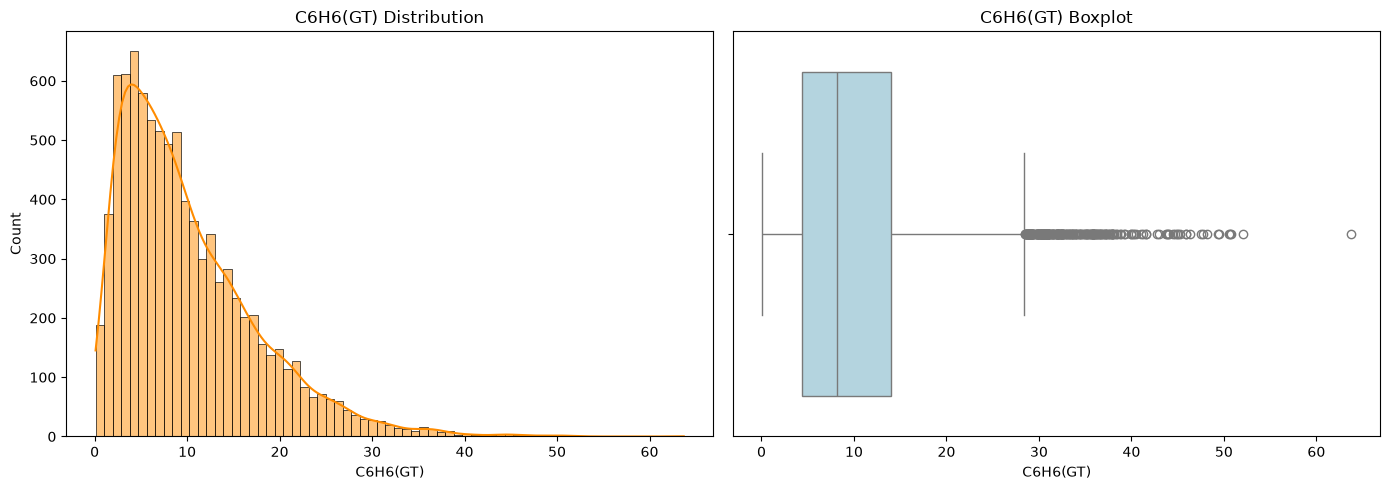

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=target_df,
    x=target,
    kde=True,
    ax=axes[0],
    color="darkorange"
)
axes[0].set_title("C6H6(GT) Distribution")
axes[0].set_xlabel("C6H6(GT)")

sns.boxplot(
    data=target_df,
    x=target,
    ax=axes[1],
    color="lightblue"
)
axes[1].set_title("C6H6(GT) Boxplot")
axes[1].set_xlabel("C6H6(GT)")

plt.tight_layout()
plt.show()

In [29]:
print("Skewness:", target_df[target].skew())
print("Kurtosis :", target_df[target].kurtosis())

Skewness: 1.3615322700276489
Kurtosis : 2.4887058855164175


In [31]:
df["year"] = df["DateTime"].dt.year
df["month"] = df["DateTime"].dt.month
df["day"] = df["DateTime"].dt.day
df["day_of_week"] = df["DateTime"].dt.dayofweek
df["hour"] = df["DateTime"].dt.hour
df["is_weekend"] = df["day_of_week"] >= 5

df[[
    "DateTime",
    "year",
    "month",
    "day_of_week",
    "hour",
    "is_weekend"
]].head()

,DateTime,year,month,day_of_week,hour,is_weekend
0,2004-03-10 18:00:00,2004,3,2,18,False
1,2004-03-10 19:00:00,2004,3,2,19,False
2,2004-03-10 20:00:00,2004,3,2,20,False
3,2004-03-10 21:00:00,2004,3,2,21,False
4,2004-03-10 22:00:00,2004,3,2,22,False


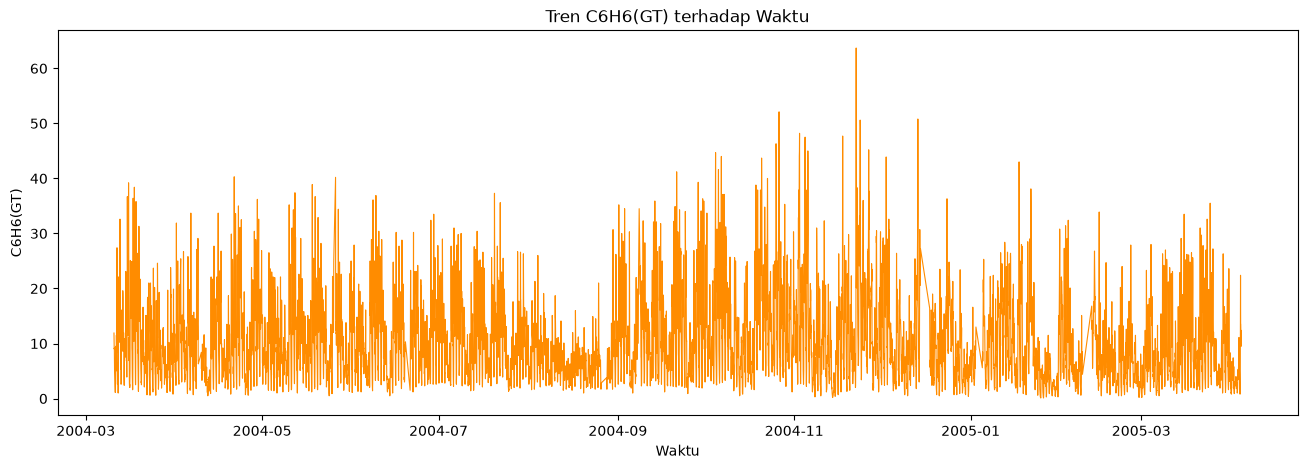

In [ ]:
plt.figure(figsize=(16, 5))

sns.lineplot(
    data=target_df,
    x="DateTime",
    y=target,
    linewidth=0.8,
    color="darkorange"
)

plt.title("Trend of C6H6(GT) over Time")
plt.xlabel("Time")
plt.ylabel("C6H6(GT)")
plt.show()

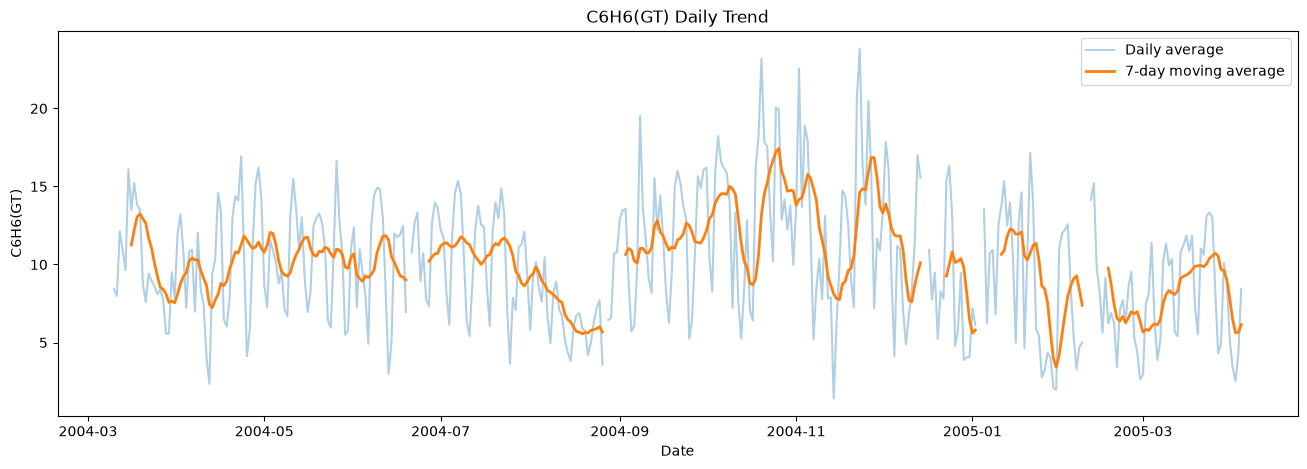

In [34]:
daily_target = (
    target_df
    .set_index("DateTime")[target]
    .resample("D")
    .mean()
)
rolling_target = daily_target.rolling(7).mean()

plt.figure(figsize=(16, 5))
plt.plot(
    daily_target,
    alpha=0.35,
    label="Daily average"
)
plt.plot(
    rolling_target,
    linewidth=2,
    label="7-day moving average"
)
plt.title("C6H6(GT) Daily Trend")
plt.xlabel("Date")
plt.ylabel("C6H6(GT)")
plt.legend()
plt.show()